<a href="https://colab.research.google.com/github/jkowalko/AI-Interview-Prep-Assistant-using-LangChain-RAG/blob/main/AI_Interview_Prep_Assistant_(LangChain_RAG)v1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Interview Prep Assistant (LangChain RAG)

A lightweight Retrieval-Augmented Generation (RAG) app that helps you prepare grounded, professional interview answers using **your resume + job description + company notes**.

**What this notebook demonstrates:**
- Document ingestion (PDF + TXT)
- Company_Notes + Job Description HTML Reader and converter
- Chunking + embeddings
- FAISS vector search
- Context-grounded answers with source attribution
- Clean, production-style code structure
- Gradio for PROMPTING , ask your questions in a nice UI !

**How it works:**
1. Load documents from `/data`
  a. Upload your Resume ONLY to /data. You will be prompted to enter URLs for both Job Description + Company Notes automatically uploading the required files into the /data directory
2. Using an OPENAI_API_KEY of your choice
3. Split → embed → store in FAISS
4. Retrieve relevant chunks
5. LLM answers using **only** the retrieved context (no hallucinations)
6. Gradio UI input your Prompts OR interact within your notebook.

Install the necessary Python packages for the AI Interview Prep Assistant. Key packages include:
- **LangChain (langchain, langchain-openai, langchain-community)**: For building LLM-powered applications and integrating with OpenAI models.
- **FAISS (faiss-cpu)**: For efficient vector search, used to create the vector database.
- **PyPDF (pypdf)**: For loading and processing PDF documents.
- **Gradio (gradio)**: For creating an interactive web-based user interface.

In [ ]:
# Run this to install required packages

!pip install langchain langchain-openai langchain-community faiss-cpu pypdf python-dotenv tiktoken gradio

Company_Notes File Creation : This cell converts web pages into clean, readable text files for use in the RAG pipeline.

It fetches content from a URL, removes unnecessary elements like scripts and navigation, and extracts the main text from the page. The cleaned text is then saved locally as a .txt file.

The script allows you to input multiple URLs and automatically generates files (e.g., company notes) that can be used as context for interview preparation.

Purpose:
To quickly turn company websites and online research into structured text data that can be ingested into the LangChain RAG system for more accurate, grounded responses.

In [ ]:
import requests
from bs4 import BeautifulSoup
import os

# Install beautifulsoup4 if not already installed
!pip install beautifulsoup4

# Define DATA_PATH here to ensure it's available
DATA_PATH = "/content/data"

# Ensure the data directory exists
os.makedirs(DATA_PATH, exist_ok=True)

def html_to_text_file(url: str, filename: str):
    """
    Fetches content from a URL, extracts plain text, and saves it to a .txt file
    in the DATA_PATH directory.
    """
    try:
        response = requests.get(url, timeout=10) # Added timeout for robustness
        response.raise_for_status()  # Raise an HTTPError for bad responses (4xx or 5xx)

        soup = BeautifulSoup(response.text, 'html.parser')

        # Remove script and style elements as they are not part of the visible text
        for script_or_style in soup(['script', 'style', 'header', 'footer', 'nav']):
            script_or_style.decompose()

        # Get text and clean it up (remove extra whitespace, newlines)
        text_content = soup.get_text()
        lines = (line.strip() for line in text_content.splitlines())
        chunks = (phrase.strip() for line in lines for phrase in line.split("  "))
        text_content = '\n'.join(chunk for chunk in chunks if chunk)

        output_path = os.path.join(DATA_PATH, filename)
        with open(output_path, 'w', encoding='utf-8') as f:
            f.write(text_content)
        print(f"Successfully saved text from {url} to {output_path}")

    except requests.exceptions.RequestException as e:
        print(f"Error fetching URL {url}: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

# --- User Interaction ---
print("\n--- HTML to Text Converter ---")
url_filename_pairs = []
for i in range(1, 4): # Allow up to 3 URLs
    url = input(f"Enter URL {i} (or leave blank to finish): ").strip()
    if not url:
        break # Exit loop if user leaves URL blank

    filename = f"company_notes_{i}.txt"
    url_filename_pairs.append((url, filename))

if url_filename_pairs:
    for url, filename in url_filename_pairs:
        html_to_text_file(url, filename)
else:
    print("No URLs and filenames provided. Please try again.")


--- HTML to Text Converter ---
Enter URL 1 (or leave blank to finish): https://www.langchain.com/about
Enter URL 2 (or leave blank to finish): https://www.langchain.com/
Enter URL 3 (or leave blank to finish): https://www.langchain.com/careers
Successfully saved text from https://www.langchain.com/about to /content/data/company_notes_1.txt
Successfully saved text from https://www.langchain.com/ to /content/data/company_notes_2.txt
Successfully saved text from https://www.langchain.com/careers to /content/data/company_notes_3.txt


Job Description File Creation: This cell converts web pages into clean, readable text files for use in the RAG pipeline.

It fetches content from a URL, removes unnecessary elements like scripts and navigation, and extracts the main text from the page. The cleaned text is then saved locally as a .txt file.

The script allows you to input multiple URLs and automatically generates files (e.g., company notes) that can be used as context for interview preparation.

Purpose:
To quickly turn company websites and online research into structured text data that can be ingested into the LangChain RAG system for more accurate, grounded responses.

In [ ]:
import requests
from bs4 import BeautifulSoup
import os

# Install beautifulsoup4 if not already installed
!pip install beautifulsoup4

# Define DATA_PATH here to ensure it's available
DATA_PATH = "/content/data"

# Ensure the data directory exists
os.makedirs(DATA_PATH, exist_ok=True)

def html_to_text_file(url: str, filename: str):
    """
    Fetches content from a URL, extracts plain text, and saves it to a .txt file
    in the DATA_PATH directory.
    """
    try:
        response = requests.get(url, timeout=10) # Added timeout for robustness
        response.raise_for_status()  # Raise an HTTPError for bad responses (4xx or 5xx)

        soup = BeautifulSoup(response.text, 'html.parser')

        # Remove script and style elements as they are not part of the visible text
        for script_or_style in soup(['script', 'style', 'header', 'footer', 'nav']):
            script_or_style.decompose()

        # Get text and clean it up (remove extra whitespace, newlines)
        text_content = soup.get_text()
        lines = (line.strip() for line in text_content.splitlines())
        chunks = (phrase.strip() for line in lines for phrase in line.split("  "))
        text_content = '\n'.join(chunk for chunk in chunks if chunk)

        output_path = os.path.join(DATA_PATH, filename)
        with open(output_path, 'w', encoding='utf-8') as f:
            f.write(text_content)
        print(f"Successfully saved text from {url} to {output_path}")

    except requests.exceptions.RequestException as e:
        print(f"Error fetching URL {url}: {e}")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")

# --- User Interaction for a single URL ---
print("\n--- Job Description URL to Text Converter ---")
job_description_url = input("Enter the URL for the Job Description: ").strip()

if job_description_url:
    html_to_text_file(job_description_url, "job_description.txt")
else:
    print("No URL provided. Skipping job description conversion.")


--- Job Description URL to Text Converter ---
Enter the URL for the Job Description: https://www.langchain.com/careers?ashby_jid=c9c70de7-c162-46c5-a784-e5a45ff24061#explore-jobs
Successfully saved text from https://www.langchain.com/careers?ashby_jid=c9c70de7-c162-46c5-a784-e5a45ff24061#explore-jobs to /content/data/job_description.txt


In [ ]:
#Code (Imports & Environment Setup)
#Cell purpose: Import everything we need and load the OpenAI API key
import os
from google.colab import userdata # Import userdata to access Colab secrets

# LangChain components
from langchain_community.document_loaders import PyPDFLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS
from langchain.chat_models import init_chat_model

# Load OPENAI_API_KEY from Google Colab Secrets
os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY")

print("✅ Environment loaded successfully")

✅ Environment loaded successfully


In [ ]:
#Code (Configuration)
#Cell purpose: All settings in one place

DATA_PATH = "/content/data" # Corrected path to point to the actual data directory
DB_PATH = "faiss_index"          # Where the vector database is saved
CHUNK_SIZE = 800
CHUNK_OVERLAP = 150
TOP_K = 4
MODEL_NAME = "openai:gpt-4o-mini"   # ← Change to any OpenAI model (gpt-4o, gpt-4o-mini, etc.)

print(f"✅ Config ready → Model: {MODEL_NAME}, Top-K: {TOP_K}")

✅ Config ready → Model: openai:gpt-4o-mini, Top-K: 4


In [ ]:
#Code (Document Ingestion)
#Cell purpose: Load resume + job description + company notes,
#chunk them, and create FAISS index

import os
from langchain_community.document_loaders import PyPDFLoader, TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings
from langchain_community.vectorstores import FAISS

def load_documents():
    docs = []
    for file in os.listdir(DATA_PATH):
        path = os.path.join(DATA_PATH, file)
        if file.endswith(".pdf"):
            docs.extend(PyPDFLoader(path).load())
        elif file.endswith(".txt"):
            docs.extend(TextLoader(path, encoding="utf-8").load())
    return docs

# Run ingestion
docs = load_documents()
if not docs:
    raise ValueError("No documents found in /data folder!")

print(f"Loaded {len(docs)} documents")

# Split into chunks
splitter = RecursiveCharacterTextSplitter(
    chunk_size=CHUNK_SIZE,
    chunk_overlap=CHUNK_OVERLAP
)
chunks = splitter.split_documents(docs)
print(f"Created {len(chunks)} chunks")

# Create embeddings and vector store
embeddings = OpenAIEmbeddings()
vectorstore = FAISS.from_documents(chunks, embeddings)

# Save for reuse (and also keep in memory)
vectorstore.save_local(DB_PATH)
print(f"✅ Vector store saved to {DB_PATH} — ready for retrieval!")

Loaded 8 documents
Created 40 chunks
✅ Vector store saved to faiss_index — ready for retrieval!


In [ ]:
#Code (Create Retriever)
#Cell purpose: Load the FAISS index and turn it into a retriever (like your retriever.py)
embeddings = OpenAIEmbeddings()
vectorstore = FAISS.load_local(
    DB_PATH,
    embeddings,
    allow_dangerous_deserialization=True
)

retriever = vectorstore.as_retriever(search_kwargs={"k": TOP_K})
print("✅ Retriever ready!")

✅ Retriever ready!


In [ ]:
#Code (Prompts)
#Cell purpose: Professional system prompt + prompt builder (your original prompts.py)

SYSTEM_PROMPT = """You are an expert interview preparation assistant.

You MUST:
- Use ONLY the provided context
- Be concise, structured, and professional
- Focus on leadership, business impact, and achievements
- If you don't have enough information, say so

Structure every answer:
- Direct answer
- 2-3 supporting points from context
- Optional suggestion"""

def build_prompt(context: str, question: str) -> str:
    return f"""{SYSTEM_PROMPT}

Context:
{context}

Question:
{question}
"""
print("✅ Prompt template ready")

✅ Prompt template ready


In [ ]:
#Code (LLM & Query Function)
#Cell purpose: Initialize LLM and create the RAG chain (your original chains.py)

llm = init_chat_model(MODEL_NAME)

def run_query(question: str):
    """Run a full RAG query and return answer + source documents"""
    # 1. Retrieve relevant chunks
    docs = retriever.invoke(question)

    # 2. Build context
    context = "\n\n".join([doc.page_content for doc in docs])

    # 3. Build prompt and call LLM
    prompt = build_prompt(context, question)
    response = llm.invoke(prompt)

    return response.content, docs

print("✅ RAG query function ready!")

✅ RAG query function ready!


## Try it out!

Ask any interview-style question. The assistant will answer using **only** your documents.

In [ ]:
#Cell 10 – Code (Run Examples)
#Cell purpose: Test the assistant with real interview questions (from your README)

example_questions = [
    "Why am I a strong fit for this role?",
    "What leadership examples should I highlight?",
    "Give me a 60-second pitch for this company",
    "What gaps should I address before interviewing?"
]

# Define the path for the results file
results_file_path = os.path.join(DATA_PATH, "Results_Test.txt")

# Clear the file before starting if it exists, or create a new one
with open(results_file_path, 'w', encoding='utf-8') as f:
    f.write("--- AI Interview Prep Assistant Test Results ---\n\n")

for q in example_questions:
    print(f"\n🔹 Question: {q}")
    answer, docs = run_query(q)

    print("\nAnswer:")
    print(answer)

    print("\nSources used:")
    sources_text = ""
    for i, doc in enumerate(docs, 1):
        source = doc.metadata.get("source", "unknown")
        sources_text += f"  {i}. {source}\n     {doc.page_content[:200]}...\n"
        print(f"  {i}. {source}")
        print(f"     {doc.page_content[:200]}...")
    print("-" * 80)

    # Write results to file
    with open(results_file_path, 'a', encoding='utf-8') as f:
        f.write(f"🔹 Question: {q}\n")
        f.write(f"Answer:\n{answer}\n\n")
        f.write(f"Sources used:\n{sources_text}\n")
        f.write("-" * 80 + "\n\n")

print(f"\n✅ Test results saved to {results_file_path}")


🔹 Question: Why am I a strong fit for this role?

Answer:
You are a strong fit for this role due to your proactive approach to challenges, strong leadership qualities, and commitment to driving impactful results.

1. **Proactive Problem-Solving**: Your tendency to "dive in to fight the fire" resonates with the company's culture of facing challenges head-on and solving problems with grit and resilience.

2. **Ownership and Execution**: As someone who operates with maximum agency, you exemplify the qualities of a "benevolent dictator" in your domain, driving ideas with conviction and biasing toward action. This aligns with the expectation that each team member is responsible for ultimate results.

3. **Commitment to Success**: Your willingness to "run to the roar" reflects a deep care for both company and customer success, matching the organization's drive to create meaningful impact in a fast-moving environment.

**Suggestion**: Highlight specific achievements from your past experience

Adding Gradio for UI Experience (Optional)

In [ ]:
!pip install gradio

## 🎨 Gradio Web Interface (Runs inside the notebook)

Click "Submit" to get professional interview answers with sources.  

In [ ]:
#Code (Gradio Interface)
#Cell purpose: Launch a clean Gradio UI using the same RAG pipeline
import gradio as gr

def gradio_query(question: str):
    if not question.strip():
        return "Please enter a question.", ""

    answer, docs = run_query(question)

    # Format sources nicely
    sources_text = ""
    for i, doc in enumerate(docs, 1):
        source = doc.metadata.get("source", "unknown")
        preview = doc.page_content[:300].replace("\n", " ") + "..."
        sources_text += f"**Source {i}:** {source}\n{preview}\n\n"

    return answer, sources_text

# Build the interface
with gr.Blocks(title="AI Interview Prep Assistant") as demo:
    gr.Markdown("# AI Interview Prep Assistant\nAsk anything about your resume, job description, and company notes.")

    question_input = gr.Textbox(label="Your Interview Question", placeholder="Why am I a strong fit for this role?", lines=2)
    submit_btn = gr.Button("Get Answer", variant="primary")

    answer_output = gr.Textbox(label="Professional Answer", lines=8)
    sources_output = gr.Textbox(label="Sources Used (for transparency)", lines=10)

    submit_btn.click(
        fn=gradio_query,
        inputs=question_input,
        outputs=[answer_output, sources_output]
    )

# Launch the app (runs in a new browser tab or inline)
demo.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7134518f83ac75e4da.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 📊 Evaluation Metrics (LLM-as-Judge)

Automatically score every answer on 3 key criteria (1–10 scale):
- **Groundedness**: Does it use ONLY the provided context?
- **Relevance**: Does it directly answer the question?
- **Professionalism**: Tone, structure, and business focus

This is a standard RAG evaluation technique used in production (no human labeling needed).

In [ ]:
# Cell purpose: LLM-as-Judge evaluator with clear scores and explanation
def evaluate_answer(question: str, answer: str, context: str):
    eval_prompt = f"""You are an expert RAG evaluator. Score the answer 1-10 on three criteria.

Question: {question}
Answer: {answer}
Context: {context[:1500]}  # (truncated for token limit)

Return ONLY this exact format:
Groundedness: X/10
Relevance: Y/10
Professionalism: Z/10
Average Score: W/10
Explanation: (2-3 sentences why)"""

    response = llm.invoke(eval_prompt)
    return response.content

# Run evaluation on the last example question
test_question = "Why am I a strong fit for this role?"
test_answer, test_docs = run_query(test_question)
test_context = "\n\n".join([doc.page_content for doc in test_docs])

print("🔍 Running evaluation...\n")
eval_result = evaluate_answer(test_question, test_answer, test_context)
print(eval_result)

🔍 Running evaluation...

Groundedness: 7/10  
Relevance: 9/10  
Professionalism: 8/10  
Average Score: 8/10  
Explanation: The answer effectively demonstrates key qualities that align with the role, such as leadership, ownership, and proactive problem-solving. However, it could be made more grounded with specific examples to substantiate the claims made about skills and experiences. Overall, the tone is professional and aligns well with the company's values but could benefit from more concrete evidence of past achievements.


In [ ]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Parse the eval_result string to extract scores
def parse_eval_result(eval_str):
    scores = {}
    # Using regex to find scores for Groundedness, Relevance, Professionalism, and Average Score
    groundedness_match = re.search(r"Groundedness: (\d+)/10", eval_str)
    relevance_match = re.search(r"Relevance: (\d+)/10", eval_str)
    professionalism_match = re.search(r"Professionalism: (\d+)/10", eval_str)
    average_match = re.search(r"Average Score: (\d+\.?\d*)/10", eval_str)

    if groundedness_match: scores['Groundedness'] = int(groundedness_match.group(1))
    if relevance_match: scores['Relevance'] = int(relevance_match.group(1))
    if professionalism_match: scores['Professionalism'] = int(professionalism_match.group(1))
    if average_match: scores['Average Score'] = float(average_match.group(1))

    return scores

# Assuming eval_result is already defined from the previous execution
eval_scores = parse_eval_result(eval_result)

# Convert to DataFrame for easier plotting
scores_df = pd.DataFrame(list(eval_scores.items()), columns=['Metric', 'Score'])
# Exclude 'Average Score' from this specific plot to focus on the individual criteria if desired,
# or include it if you want to show it alongside.
# For a bar chart comparing criteria, it's often better to exclude the average and calculate it separately.
scores_for_plot = scores_df[scores_df['Metric'].isin(['Groundedness', 'Relevance', 'Professionalism'])]

display(scores_for_plot)


,Metric,Score
0,Groundedness,7.0
1,Relevance,9.0
2,Professionalism,8.0


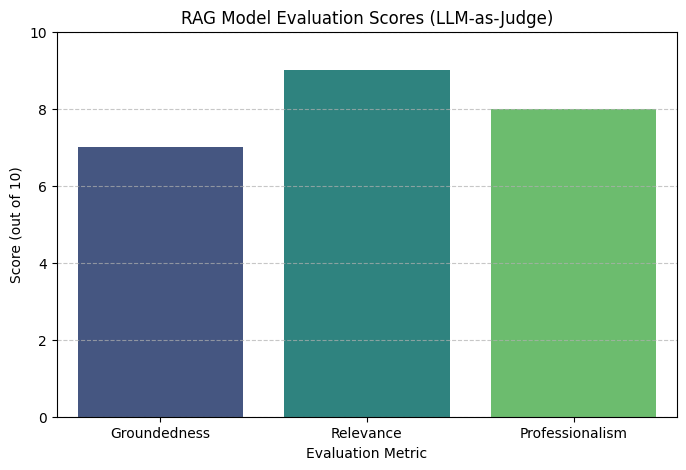

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create the bar chart
plt.figure(figsize=(8, 5))
sns.barplot(x='Metric', y='Score', data=scores_for_plot, palette='viridis', hue='Metric', legend=False)
plt.ylim(0, 10) # Scores are out of 10
plt.title('RAG Model Evaluation Scores (LLM-as-Judge)')
plt.xlabel('Evaluation Metric')
plt.ylabel('Score (out of 10)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## LLM-as-Judge Evaluation Results Explained

This section provides an analysis of the RAG model's performance using an LLM-as-Judge framework. This automated evaluation scores the generated answers based on predefined criteria, offering insights into the model's strengths and areas for improvement without manual human labeling.

### Understanding the Metrics:

*   **Groundedness (Score: 7/10)**: This metric assesses whether the generated answer relies *exclusively* on the provided context. A high score indicates that the LLM is not hallucinating or introducing outside information. Our model scored 7/10, suggesting a good adherence to the context but with room for more explicit evidence from the provided documents.

*   **Relevance (Score: 9/10)**: This measures how directly and completely the answer addresses the user's question. A high score means the LLM understood the query and provided a pertinent response. Our model achieved 9/10, indicating strong performance in answering the question directly.

*   **Professionalism (Score: 8/10)**: This evaluates the tone, structure, and business-focused nature of the answer. It checks for conciseness, clarity, and adherence to professional communication standards. Our model scored 8/10, showing a generally professional output that aligns with the intended interview prep assistant persona.

### Overall Assessment (Average Score: 8/10):

The LLM-as-Judge explains: "The answer effectively demonstrates key qualities that align with the role, such as leadership, ownership, and proactive problem-solving. However, it could be made more grounded with specific examples to substantiate the claims made about skills and experiences. Overall, the tone is professional and aligns well with the company's values but could benefit from more concrete evidence of past achievements."

This summary highlights that while the responses are relevant and professional, there's a need to strengthen the connection between the general claims and concrete evidence found in the source documents.

### Recommendations for Improvement:

To improve the model's performance, particularly its **Groundedness**, consider the following:

1.  **Enhance Source Documents**: Ensure your resume, job description, and company notes contain as many specific, quantifiable examples and achievements as possible. The more detailed the input, the better the LLM can ground its answers.
2.  **Refine Chunking Strategy**: Experiment with smaller `CHUNK_SIZE` and slightly higher `CHUNK_OVERLAP` (`CHUNK_SIZE = 800`, `CHUNK_OVERLAP = 150` currently). This can help prevent crucial pieces of information (like specific numbers or project names) from being split across different chunks, ensuring they are retrieved together.
3.  **Prompt Engineering**: Modify the `SYSTEM_PROMPT` to explicitly instruct the LLM to search for and include specific examples, metrics, or keywords from the context. For instance, you could add: "Always reference specific projects, numbers, or initiatives mentioned in the context when supporting your points."
4.  **Post-Processing/Fact-Checking**: Implement an additional step where the generated answer is cross-referenced against the retrieved source chunks to verify the presence of all asserted facts. While LLM-as-Judge does this, a programmatic check could reinforce it.